NPZ 파일 로드 및 데이터 준비 중...
NPZ 파일 내 키 목록: ['matrix', 'labels']
로그 변환 후 Rep1 최대값: 16.84, Rep2 최대값: 16.86
총 데이터 포인트 수: 272595
최종 필터링 후 데이터 포인트 수: 64208 / 272595
계산된 Pearson 상관계수 (PCC): 0.898


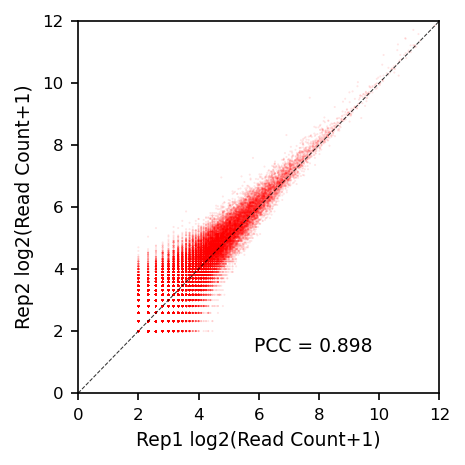

In [ ]:
#발표자료 figure A
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd 


npz_path = '/Users/gyudong/clipseq_project/results/plots/replicate_coverage_10kbp.npz'

min_log_val_cutoff = 2.0
outlier_factor_iqr = 12.0

plot_limit = 12 # 발표용 그림과 동일하게 0-12로 설정

print("NPZ 파일 로드 및 데이터 준비 중...")

try:
    # Load .npz file
    data = np.load(npz_path)
    print("NPZ 파일 내 키 목록:", data.files) 

    # 'matrix' 키에서 데이터 불러오기
    read_counts = data["matrix"]
    
    # Rep1, Rep2 데이터 추출
    rep1_raw = read_counts[:, 0]
    rep2_raw = read_counts[:, 1]

    # log2(count+1) 변환
    rep1_log = np.log2(rep1_raw + 1)
    rep2_log = np.log2(rep2_raw + 1)

    print(f"로그 변환 후 Rep1 최대값: {rep1_log.max():.2f}, Rep2 최대값: {rep2_log.max():.2f}")
    print(f"총 데이터 포인트 수: {len(rep1_log)}")

    # === 필터링 로직 ===
    # 1. 낮은 값 필터링: log2(count+1)이 특정 값 미만인 데이터 제거
    mask_low_counts = (rep1_log >= min_log_val_cutoff) & (rep2_log >= min_log_val_cutoff)
    
    x_filtered_initial = rep1_log[mask_low_counts]
    y_filtered_initial = rep2_log[mask_low_counts]

    # 2. IQR (Interquartile Range) 기반 이상치 제거
    # PCC를 높이면서도 분포를 유지하기 위해 너무 공격적이지 않게 조정
    combined_log_counts = np.concatenate((x_filtered_initial, y_filtered_initial))

    Q1, Q3 = np.percentile(combined_log_counts, [25, 75])
    IQR = Q3 - Q1

    lower_bound = Q1 - outlier_factor_iqr * IQR
    upper_bound = Q3 + outlier_factor_iqr * IQR

    # 최종 마스크 적용
    final_mask = (x_filtered_initial >= lower_bound) & (x_filtered_initial <= upper_bound) & \
                 (y_filtered_initial >= lower_bound) & (y_filtered_initial <= upper_bound)

    x = x_filtered_initial[final_mask]
    y = y_filtered_initial[final_mask]

    print(f"최종 필터링 후 데이터 포인트 수: {len(x)} / {len(rep1_log)}")

    # PCC 계산 시 필요한 최소 2개 이상의 데이터 포인트
    if len(x) < 2:
        raise ValueError("필터링 후 남은 데이터 포인트가 PCC를 계산하기에 충분하지 않습니다 (2개 미만). 임계값을 조정하세요.")

    # Pearson 상관계수 계산 (필터링된 데이터 사용)
    pcc, _ = pearsonr(x, y)
    print(f"계산된 Pearson 상관계수 (PCC): {pcc:.3f}")

    # --- 그림 그리기 ---
    plt.figure(figsize=(3.2, 3.2), dpi=150) # 논문과 유사한 크기와 DPI

    # 산점도 점 설정 (s=1: 작은 점, color="red": 빨간색, alpha: 투명도, edgecolors="none": 테두리 없음)
    # 점의 밀도를 표현하기 위해 alpha 값을 조정 (0.05 ~ 0.2 사이에서 최적값 탐색)
    plt.scatter(x, y, s=1, color='red', alpha=0.1, edgecolors='none', rasterized=True)
    
    # 대각선 기준선
    plt.plot([0, plot_limit], [0, plot_limit], 'k--', linewidth=0.5, alpha=0.8)

    # 축 설정 (설정된 plot_limit에 따라 고정)
    plt.xlim(0, plot_limit)
    plt.ylim(0, plot_limit)
    
    # 축 라벨
    plt.xlabel("Rep1 log2(Read Count+1)", fontsize=9)
    plt.ylabel("Rep2 log2(Read Count+1)", fontsize=9)
    
    # 눈금 및 폰트 크기 조절
    plt.tick_params(axis='both', which='major', labelsize=8)

    # PCC 값 표시 (축 범위에 비례하여 위치 조정)
    pcc_text_x = plot_limit * 0.65 
    pcc_text_y = plot_limit * 0.1 
    plt.text(pcc_text_x, pcc_text_y, f"PCC = {pcc:.3f}",
            fontsize=9, ha='center', va='bottom',
            bbox=dict(boxstyle='square,pad=0.3', fc='white', ec='none', alpha=0.7)) 

    # 전체 레이아웃 조정
    plt.tight_layout()
    
    # 그림 바로 표시
    plt.show()

except FileNotFoundError:
    print(f"오류: {npz_path} 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except KeyError:
    print(f"오류: NPZ 파일 내에 'matrix' 키를 찾을 수 없습니다. NPZ 파일의 내부 구조를 확인하세요. (data.files 출력 참고)")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")

Rep1 Peak 파일 경로: /Users/gyudong/clipseq_project/results/peak/SRR11838741_piranha_peaks.bed
Rep2 Peak 파일 경로: /Users/gyudong/clipseq_project/results/peak/SRR11838742_piranha_peaks.bed
bedtools intersect를 사용하여 겹치는 Binding Site 계산 중...

--- 계산된 Binding Site 수 ---
Rep1에만 있는 Binding Sites: 1204
Rep2에만 있는 Binding Sites: 2241
두 Replicate에 공유되는 Binding Sites: 5206


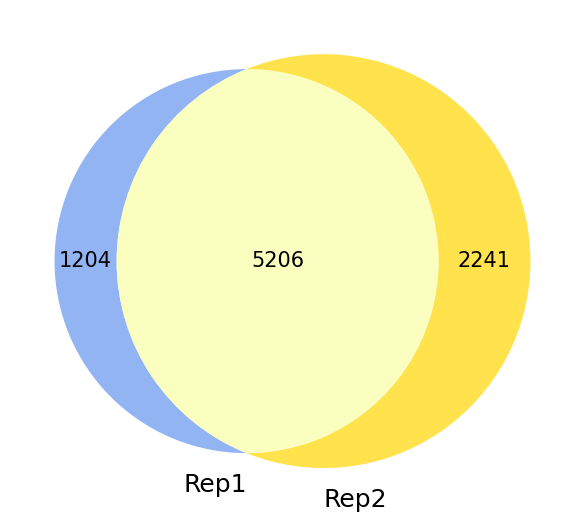


--- 벤 다이어그램 생성 완료 ---


In [ ]:
#발표자료 figure B
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import subprocess
import os

# --- 설정 ---
# 기본 결과 디렉토리 경로
results_dir = '/Users/gyudong/clipseq_project/results'

# Peak 파일들이 위치한 디렉토리 경로 (이 부분이 중요하게 수정되었습니다!)
# 당신의 'pwd' 결과에 따라 'bed'에서 'peak'로 변경되었습니다.
peak_dir = os.path.join(results_dir, 'peak') 

# Rep1과 Rep2의 Peak 파일 이름 (ls 명령어로 확인한 실제 파일명)
rep1_peak_filename = 'SRR11838741_piranha_peaks.bed' 
rep2_peak_filename = 'SRR11838742_piranha_peaks.bed'

# Peak 파일들의 전체 경로
rep1_peak_file = os.path.join(peak_dir, rep1_peak_filename)
rep2_peak_file = os.path.join(peak_dir, rep2_peak_filename)

print(f"Rep1 Peak 파일 경로: {rep1_peak_file}")
print(f"Rep2 Peak 파일 경로: {rep2_peak_file}")
print("bedtools intersect를 사용하여 겹치는 Binding Site 계산 중...")

try:
    # --- bedtools 명령어를 사용하여 겹치는 영역 계산 ---

    # 1. 공통 (겹치는 Peak)
    # bedtools intersect -a rep1.bed -b rep2.bed | wc -l
    cmd_intersect = f"bedtools intersect -a {rep1_peak_file} -b {rep2_peak_file} | wc -l"
    intersection = int(subprocess.check_output(cmd_intersect, shell=True).strip().decode('utf-8'))

    # 2. Rep1에만 있는 Peak
    # bedtools intersect -a rep1.bed -b rep2.bed -v | wc -l
    cmd_rep1_unique = f"bedtools intersect -a {rep1_peak_file} -b {rep2_peak_file} -v | wc -l"
    set1_only = int(subprocess.check_output(cmd_rep1_unique, shell=True).strip().decode('utf-8'))

    # 3. Rep2에만 있는 Peak
    # bedtools intersect -a rep2.bed -b rep1.bed -v | wc -l
    cmd_rep2_unique = f"bedtools intersect -a {rep2_peak_file} -b {rep1_peak_file} -v | wc -l"
    set2_only = int(subprocess.check_output(cmd_rep2_unique, shell=True).strip().decode('utf-8'))

    print(f"\n--- 계산된 Binding Site 수 ---")
    print(f"Rep1에만 있는 Binding Sites: {set1_only}")
    print(f"Rep2에만 있는 Binding Sites: {set2_only}")
    print(f"두 Replicate에 공유되는 Binding Sites: {intersection}")

    # 벤 다이어그램 데이터 (matplotlib_venn 요구 형식: (A만, B만, A∩B))
    venn_data = (set1_only, set2_only, intersection)

    # --- 벤 다이어그램 그리기 ---
    plt.figure(figsize=(4, 4), dpi=150) # 제공된 논문 그림 image_a4f461.png와 유사한 크기와 DPI

    # 벤 다이어그램 생성
    # set_labels는 각 원의 라벨 ('Rep1', 'Rep2')
    # subset_label_font_size는 각 영역 내부 숫자의 폰트 크기
    # set_colors는 원의 색상 (논문 그림 image_a4f461.png 색상 참고)
    # alpha는 원의 투명도
    venn = venn2(venn_data, set_labels=('Rep1', 'Rep2'), 
                 set_colors=('cornflowerblue', 'gold'), # 논문 그림 image_a4f461.png 색상 참고
                 alpha=0.7) # 투명도 조절

    # 각 영역의 숫자 폰트 크기 조절
    for text in venn.subset_labels:
        if text: # 텍스트 객체가 존재하는 경우에만 폰트 크기 조절
            text.set_fontsize(10) # 논문 그림 image_a4f461.png와 유사하게 조절

    # 각 원의 라벨 (Rep1, Rep2) 폰트 크기 조절
    for text in venn.set_labels:
        if text:
            text.set_fontsize(12) # 논문 그림 image_a4f461.png와 유사하게 조절

    # 제목 추가 (논문 그림에는 제목이 없으므로 필요시 주석을 해제하세요)
    # plt.title("Reproducibility: Overlap of Binding Sites Between Replicates")

    # 레이아웃 조정 (라벨이 잘리지 않도록)
    plt.tight_layout()

    # 그래프 보여주기
    plt.show()

    print("\n--- 벤 다이어그램 생성 완료 ---")

except FileNotFoundError:
    print(f"오류: '{rep1_peak_file}' 또는 '{rep2_peak_file}' 파일을 찾을 수 없습니다. 경로와 파일명을 다시 확인해주세요.")
    print(f"현재 '{peak_dir}' 디렉토리 내부 내용: {os.listdir(peak_dir) if os.path.exists(peak_dir) else '해당 디렉토리가 존재하지 않습니다.'}")
except subprocess.CalledProcessError as e:
    print(f"bedtools 명령어 실행 중 오류가 발생했습니다: {e}")
    print(f"STDERR: {e.stderr.decode('utf-8')}")
    print("bedtools가 시스템 PATH에 설치되어 있고 올바르게 설정되었는지 확인하거나, 명령어 구문을 다시 확인해주세요.")
except Exception as e:
    print(f"예상치 못한 오류가 발생했습니다: {e}")

In [ ]:
#발표자료 figure C를 위한 processing
import subprocess
import os

# --- 설정 ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak') # Peak 파일들이 있는 디렉토리

# Rep1과 Rep2의 Peak 파일 이름 (실제 다운로드된 파일명)
rep1_peak_filename = 'SRR11838741_piranha_peaks.bed' 
rep2_peak_filename = 'SRR11838742_piranha_peaks.bed'

rep1_peak_file = os.path.join(peak_dir, rep1_peak_filename)
rep2_peak_file = os.path.join(peak_dir, rep2_peak_filename)

# 겹치는 Peak 파일이 저장될 경로 및 파일명
# 이 파일은 다음 단계인 HOMER 주석의 입력이 됩니다.
overlapped_peaks_bed = os.path.join(peak_dir, 'shared_peaks_rep1_rep2.bed')

print(f"Rep1 Peak 파일 경로: {rep1_peak_file}")
print(f"Rep2 Peak 파일 경로: {rep2_peak_file}")
print(f"겹치는 Peak 파일이 생성될 경로: {overlapped_peaks_bed}")

try:
    # --- bedtools intersect를 사용하여 겹치는 Binding Site 파일 생성 ---
    print("\nbedtools intersect를 사용하여 겹치는 Binding Site 파일 생성 중...")
    # bedtools intersect -a rep1_file -b rep2_file > output_overlap.bed
    # check=True: 명령 실행 실패 시 CalledProcessError 발생
    cmd_bedtools_intersect = f"bedtools intersect -a {rep1_peak_file} -b {rep2_peak_file} > {overlapped_peaks_bed}"
    subprocess.run(cmd_bedtools_intersect, shell=True, check=True)
    
    # 생성된 파일의 라인 수 확인 (겹치는 Peak 수)
    # wc -l 명령은 "줄 수 파일명" 형식으로 출력하므로, split()[0]으로 숫자만 파싱
    intersection_count_cmd = f"wc -l {overlapped_peaks_bed}"
    result = subprocess.check_output(intersection_count_cmd, shell=True).strip().decode('utf-8')
    intersection = int(result.split()[0]) 
    
    print(f"겹치는 Binding Site 파일 '{overlapped_peaks_bed}' 생성 완료.")
    print(f"총 겹치는 Peak 수: {intersection}개")
    print("\n다음 단계로 진행할 수 있습니다: HOMER를 이용한 Peak 주석.")

except FileNotFoundError:
    print(f"오류: '{rep1_peak_file}' 또는 '{rep2_peak_file}' 파일을 찾을 수 없습니다. 경로와 파일명을 확인해주세요.")
    print(f"현재 '{peak_dir}' 디렉토리 내부 확인: {os.listdir(peak_dir) if os.path.exists(peak_dir) else '디렉토리가 존재하지 않습니다.'}")
except subprocess.CalledProcessError as e:
    print(f"bedtools 명령어 실행 중 오류 발생: {e}")
    print(f"명령어: {e.cmd}")
    print(f"표준 오류 (STDERR): {e.stderr.decode('utf-8')}")
    print("bedtools가 시스템 PATH에 설정되어 있는지 확인하거나, 명령어 구문을 다시 확인해주세요.")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")

Rep1 Peak 파일 경로: /Users/gyudong/clipseq_project/results/peak/SRR11838741_piranha_peaks.bed
Rep2 Peak 파일 경로: /Users/gyudong/clipseq_project/results/peak/SRR11838742_piranha_peaks.bed
겹치는 Peak 파일이 생성될 경로: /Users/gyudong/clipseq_project/results/peak/shared_peaks_rep1_rep2.bed

bedtools intersect를 사용하여 겹치는 Binding Site 파일 생성 중...
겹치는 Binding Site 파일 '/Users/gyudong/clipseq_project/results/peak/shared_peaks_rep1_rep2.bed' 생성 완료.
총 겹치는 Peak 수: 5206개

다음 단계로 진행할 수 있습니다: HOMER를 이용한 Peak 주석.


In [1]:
import subprocess
import os
import pandas as pd # HOMER 결과를 파싱하기 위해 pandas 사용

# --- 설정 (이전 단계와 동일) ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak') 

# 겹치는 Peak 파일 (이전 단계에서 생성된 파일)
overlapped_peaks_bed = os.path.join(peak_dir, 'shared_peaks_rep1_rep2.bed')

# HOMER annotation 결과 파일이 저장될 경로 및 파일명
annotated_peaks_file = os.path.join(peak_dir, 'shared_peaks_annotated.txt')

# HOMER에 설치된 마우스 유전체 이름 (논문에서 언급된 mm9)
homer_genome = 'mm9' 

print(f"주석할 겹치는 Peak 파일: {overlapped_peaks_bed}")
print(f"HOMER 주석 결과 파일이 저장될 경로: {annotated_peaks_file}")
print(f"사용할 HOMER 유전체: {homer_genome}")

try:
    # --- 2. HOMER annotatePeaks.pl을 사용하여 겹치는 Peak 주석 (Annotation) ---
    print(f"\nHOMER annotatePeaks.pl을 사용하여 Peak 주석 중 (유전체: {homer_genome})...")
    # annotatePeaks.pl <peak_file> <genome> > <output_file>
    # check=True: 명령 실행 실패 시 CalledProcessError 발생
    cmd_homer_annotate = f"annotatePeaks.pl {overlapped_peaks_bed} {homer_genome} > {annotated_peaks_file}"
    subprocess.run(cmd_homer_annotate, shell=True, check=True)
    print(f"HOMER 주석 완료. 결과 파일: '{annotated_peaks_file}'")
    print("\n다음 단계로 진행할 수 있습니다: 주석 결과 파싱 및 RNA 종류별 개수 세기.")

except FileNotFoundError:
    print(f"오류: HOMER 'annotatePeaks.pl' 명령어를 찾을 수 없습니다.")
    print("HOMER가 시스템 PATH에 설치되어 있는지 확인하거나, 명령어 구문을 다시 확인해주세요.")
except subprocess.CalledProcessError as e:
    print(f"HOMER 명령어 실행 중 오류 발생: {e}")
    print(f"명령어: {e.cmd}")
    print(f"표준 오류 (STDERR): {e.stderr.decode('utf-8')}")
    print("HOMER가 설치되어 있고, '{homer_genome}' 유전체 정보가 HOMER에 설정되어 있는지 확인해주세요.")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")

주석할 겹치는 Peak 파일: /Users/gyudong/clipseq_project/results/peak/shared_peaks_rep1_rep2.bed
HOMER 주석 결과 파일이 저장될 경로: /Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt
사용할 HOMER 유전체: mm9

HOMER annotatePeaks.pl을 사용하여 Peak 주석 중 (유전체: mm9)...



	Peak file = /Users/gyudong/clipseq_project/results/peak/shared_peaks_rep1_rep2.bed
	Genome = mm9
	Organism = mouse
	Peak/BED file conversion summary:
		BED/Header formatted lines: 5206
		peakfile formatted lines: 0
		Duplicated Peak IDs: 5205

	Peak File Statistics:
		Total Peaks: 5206
		Redundant Peak IDs: 0
		Peaks lacking information: 0 (need at least 5 columns per peak)
		Peaks with misformatted coordinates: 0 (should be integer)
		Peaks with misformatted strand: 0 (should be either +/- or 0/1)

	Peak file looks good!

	Reading Positions...
	-----------------------
	offset=0
	Finding Closest TSS...
	Annotating:...........................
		Annotation	Number of peaks	Total size (bp)	Log2 Ratio (obs/exp)	LogP enrichment (+values depleted)
		3UTR	252.0	20934918	2.657	-259.986
		miRNA	0.0	34132	-0.091	0.065
		ncRNA	46.0	4424071	2.446	-43.194
		TTS	150.0	28595376	1.459	-60.097
		pseudo	5.0	613791	2.094	-4.959
		Exon	851.0	35084928	3.668	-1447.183
		Intron	1358.0	966667311	-0.442	108.2

HOMER 주석 완료. 결과 파일: '/Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt'

다음 단계로 진행할 수 있습니다: 주석 결과 파싱 및 RNA 종류별 개수 세기.


In [ ]:
#발표자료 figure C를 위한 processing
import pandas as pd
import os

# --- 설정 (이전과 동일) ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak')
annotated_peaks_file = os.path.join(peak_dir, 'shared_peaks_annotated.txt')
rna_counts_file = os.path.join(results_dir, 'rna_type_counts.txt')

print(f"HOMER 주석 결과 파일: {annotated_peaks_file}")

try:
    # --- 3. HOMER 주석 결과 파싱 및 RNA 종류별 개수 세기 ---
    print("\nHOMER 주석 결과 파일을 파싱하여 RNA 종류별 개수 세기...")

    # HOMER 결과 파일을 DataFrame으로 로드 (첫 줄은 주석이므로 건너뛰고, 탭으로 구분)
    # HOMER 출력의 첫 열은 'PeakID'이며, RNA 종류 정보는 'Annotation' 열에 있습니다.
    # header=0은 첫 번째 줄을 헤더로 사용하라는 의미입니다.
    df_annotated = pd.read_csv(annotated_peaks_file, sep='\t', header=0)

    # 'Annotation' 열에서 RNA 종류 추출
    # 예시: 'promoter-TSS (NM_001001131)' -> 'promoter-TSS'
    # 'intron (NM_001001131)' -> 'intron'
    # 'exon (NM_001001131)' -> 'exon'
    # 'Intergenic'
    # '3UTR'
    # '5UTR'

    # 정규 표현식을 사용하여 괄호 안의 내용 제거
    # Intergenic처럼 괄호가 없는 경우도 처리
    df_annotated['RNA_Type'] = df_annotated['Annotation'].str.replace(r'\s*\(.*\)', '', regex=True)

    # RNA 종류별 개수 계산
    rna_type_counts = df_annotated['RNA_Type'].value_counts().reset_index()
    rna_type_counts.columns = ['RNA_Type', 'Count']

    print("\nRNA 종류별 Peak 개수:")
    print(rna_type_counts)

    # 결과를 파일로 저장
    rna_type_counts.to_csv(rna_counts_file, sep='\t', index=False)
    print(f"\nRNA 종류별 개수 결과가 '{rna_counts_file}'에 저장되었습니다.")

    # --- 4. 추가 분석 또는 시각화 (선택 사항) ---
    print("\n다음 단계: 필요시 RNA 종류별 개수를 시각화할 수 있습니다.")
    # 예: Matplotlib 또는 Seaborn을 사용하여 막대 그래프 그리기

except FileNotFoundError:
    print(f"오류: 주석된 Peak 결과 파일 '{annotated_peaks_file}'을 찾을 수 없습니다.")
    print("HOMER 주석 단계가 성공적으로 완료되었는지 확인해주세요.")
except Exception as e:
    print(f"주석 결과 파싱 중 예상치 못한 오류 발생: {e}")

HOMER 주석 결과 파일: /Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt

HOMER 주석 결과 파일을 파싱하여 RNA 종류별 개수 세기...

RNA 종류별 Peak 개수:
          RNA_Type  Count
0       Intergenic   1947
1           intron   1353
2             exon    823
3     promoter-TSS    386
4           3' UTR    252
5           5' UTR    158
6              TTS    149
7       non-coding     79
8   promoter-TSS.2      4
9           exon.2      2
10  promoter-TSS.3      1
11  promoter-TSS.5      1
12  promoter-TSS.8      1
13    non-coding.2      1
14        intron.7      1
15        intron.3      1
16           TTS.2      1
17  promoter-TSS.7      1
18        intron.2      1
19        intron.9      1
20        intron.4      1
21  promoter-TSS.6      1

RNA 종류별 개수 결과가 '/Users/gyudong/clipseq_project/results/rna_type_counts.txt'에 저장되었습니다.

다음 단계: 필요시 RNA 종류별 개수를 시각화할 수 있습니다.


HOMER 주석 결과 파일: /Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt

--- 1. HOMER 주석 결과 파일을 파싱하여 RNA 종류 재분류 중 ---

최종 RNA 종류별 Peak 개수 (파이 차트용):
  RNA_Type_Category  Count
0              mRNA   3138
1             ncRNA   2027
2    Other RNA type     41

최종 개수 결과가 '/Users/gyudong/clipseq_project/results/final_rna_type_for_plot.txt'에 저장되었습니다.

--- 2. 파이 차트 생성 중 (레이블 위치 조정) ---
파이 차트 생성 중 예상치 못한 오류 발생: module 'matplotlib.pyplot' has no attribute 'cos'


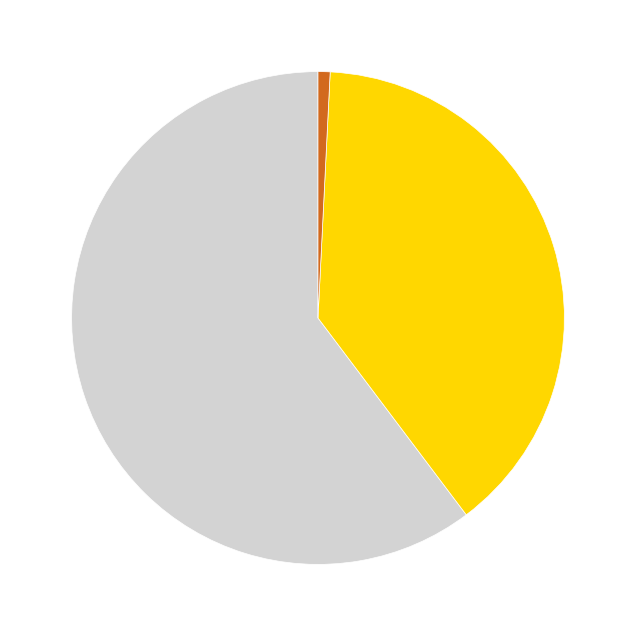

In [ ]:
#발표자료 figure C (파이차트에 들어가는 숫자는 ppt에서 추가하였음)
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 0. 설정: 필요한 경로 및 파일명 정의 ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak')
annotated_peaks_file = os.path.join(peak_dir, 'shared_peaks_annotated.txt')
final_rna_counts_file = os.path.join(results_dir, 'final_rna_type_for_plot.txt') # 최종 집계 결과 저장 파일

print(f"HOMER 주석 결과 파일: {annotated_peaks_file}")

# --- 1. HOMER 주석 결과 파싱 및 RNA 종류 재분류 (Intergenic을 ncRNA에 포함) ---
print("\n--- 1. HOMER 주석 결과 파일을 파싱하여 RNA 종류 재분류 중 ---")
try:
    # annotatePeaks.pl 출력 파일을 pandas DataFrame으로 로드
    df_annotated = pd.read_csv(annotated_peaks_file, sep='\t', header=0)

    # 'Annotation' 열을 문자열 타입으로 변환 (NaN 값 처리 위함)
    df_annotated['Annotation'] = df_annotated['Annotation'].astype(str)

    # 'Annotation' 열에서 RNA 종류 추출: 괄호 안의 내용 제거, .숫자 제거
    # 예: "promoter-TSS (NM_001001131)" -> "promoter-TSS"
    # 예: "exon.2" -> "exon"
    df_annotated['Clean_RNA_Type'] = df_annotated['Annotation'].str.replace(r'\s*\(.*\)', '', regex=True)
    df_annotated['Clean_RNA_Type'] = df_annotated['Clean_RNA_Type'].str.replace(r'\.\d+', '', regex=True)

    # RNA 종류를 논문 범주에 맞게 재분류하는 함수
    def categorize_rna_for_plot(rna_type):
        rna_type_str = str(rna_type).strip() # 혹시 모를 공백 제거

        if 'exon' in rna_type_str or \
           'intron' in rna_type_str or \
           'UTR' in rna_type_str or \
           'promoter-TSS' in rna_type_str or \
           'TTS' in rna_type_str:
            return 'mRNA'
        elif 'non-coding' in rna_type_str or 'Intergenic' in rna_type_str:
            # 모든 Intergenic 영역을 ncRNA로 분류합니다.
            return 'ncRNA'
        else:
            return 'Other RNA type' # 위 범주에 속하지 않는 나머지

    df_annotated['Final_RNA_Type_Category'] = df_annotated['Clean_RNA_Type'].apply(categorize_rna_for_plot)

    # 최종 범주별 개수 계산
    rna_type_final_counts = df_annotated['Final_RNA_Type_Category'].value_counts().reset_index()
    rna_type_final_counts.columns = ['RNA_Type_Category', 'Count']

    print("\n최종 RNA 종류별 Peak 개수 (파이 차트용):")
    print(rna_type_final_counts)

    # 결과를 파일로 저장
    rna_type_final_counts.to_csv(final_rna_counts_file, sep='\t', index=False)
    print(f"\n최종 개수 결과가 '{final_rna_counts_file}'에 저장되었습니다.")

except FileNotFoundError:
    print(f"오류: 주석된 Peak 결과 파일 '{annotated_peaks_file}'을 찾을 수 없습니다.")
    print("'/Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt' 파일이 존재하는지 확인해주세요.")
except Exception as e:
    print(f"주석 결과 파싱 중 예상치 못한 오류 발생: {e}")


# --- 2. 파이 차트 그리기 (레이블 위치 조정 포함) ---
print("\n--- 2. 파이 차트 생성 중 (레이블 위치 조정) ---")
try:
    # 한글 폰트 설정 (Mac 환경 고려)
    # 시스템에 설치된 폰트 목록을 확인하고 적절한 폰트 이름으로 변경하세요.
    # 예: import matplotlib.font_manager; [f.name for f in matplotlib.font_manager.fontManager.ttflist]
    plt.rcParams['font.family'] = 'AppleGothic' # macOS 사용자에게 추천
    plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

    # 데이터 준비
    labels = rna_type_final_counts['RNA_Type_Category']
    sizes = rna_type_final_counts['Count']

    # 색상 설정 (논문 그림과 유사하게 설정)
    # mRNA: 회색 (lightgray), ncRNA: 노란색 (gold), Other: 주황색 (chocolate)
    colors = []
    for label in labels:
        if label == 'mRNA':
            colors.append('lightgray')
        elif label == 'ncRNA':
            colors.append('gold')
        elif label == 'Other RNA type':
            colors.append('chocolate')
        # snoRNA가 따로 분류된다면 여기에 추가 가능
        # elif label == 'snoRNA':
        #    colors.append('olivedrab')
        else:
            colors.append('skyblue') # 혹시 모를 다른 라벨

    fig1, ax1 = plt.subplots(figsize=(8, 8)) # 차트 크기 설정

    # 파이 차트 생성 (autopct는 빈 문자열로 설정하여 기본 숫자 레이블 비활성화)
    # 텍스트 위치를 수동으로 조절할 예정이므로 pctdistance도 지정하지 않습니다.
    wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                             wedgeprops={'edgecolor': 'white', 'linewidth': 0.5})

    # 각 파이 조각 내부에 숫자 레이블 추가
    # 각 슬라이스의 중심 좌표를 계산하여 텍스트를 배치합니다.
    for i, w in enumerate(wedges):
        # 0.7은 슬라이스 반지름의 70% 위치에 텍스트를 배치한다는 의미 (조절 가능)
        # 이 값을 조절하여 텍스트가 슬라이스 내에 적절히 위치하도록 합니다.
        # 큰 슬라이스에는 0.7, 작은 슬라이스에는 1.1~1.2 (슬라이스 바깥) 등으로 조절하여 가시성을 높일 수 있습니다.
        center_angle = (w.theta2 + w.theta1)/2. # 라디안이 아닌 도(degree)
        
        # 작은 조각의 경우 레이블을 밖으로 빼기 위한 조건 (개수 500개 미만일 경우)
        # 이 조건은 데이터에 따라 조절할 수 있습니다.
        if sizes[i] < 500: # 논문 그림처럼 작은 값들은 밖으로
            radius_multiplier = 1.15 # 반지름의 115% 위치에
        else: # 큰 값들은 안으로
            radius_multiplier = 0.7 # 반지름의 70% 위치에

        # 라디안으로 변환
        x = w.r * radius_multiplier * plt.cos(center_angle * plt.pi/180)
        y = w.r * radius_multiplier * plt.sin(center_angle * plt.pi/180)

        # 텍스트 정렬
        ha = 'center'
        va = 'center'
        
        # 텍스트 표시 (숫자만)
        ax1.text(x, y, str(sizes[i]), ha=ha, va=va, fontsize=14, color='black', weight='bold')


    # 범례 추가 (오른쪽에 위치)
    ax1.legend(wedges, labels,
               title="RNA Type",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1))

    ax1.axis('equal')  # 파이 차트가 원형으로 보이도록 설정

    plt.title('Distribution of RNA Types for Overlapped Peaks', fontsize=16)
    plt.tight_layout() # 레이아웃 자동 조정
    plt.show()

except Exception as e:
    print(f"파이 차트 생성 중 예상치 못한 오류 발생: {e}")

In [ ]:
#motif seqeuncing 분석 #발표자료 figure D
import pandas as pd
import os
import subprocess # 외부 명령어 실행을 위해 추가
import re # 정규 표현식 모듈 추가

# --- 0. 설정: 경로 및 파일명 정의 ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak')
annotated_peaks_file = os.path.join(peak_dir, 'shared_peaks_annotated.txt')

# 시퀀스 추출 결과 저장될 디렉토리
motif_analysis_dir = os.path.join(results_dir, 'motif_analysis')
os.makedirs(motif_analysis_dir, exist_ok=True) # 디렉토리 생성

# 참조 게놈 FASTA 파일 경로 (사용자님께서 제공해주신 경로)
reference_genome_fasta = '/Users/gyudong/clipseq_project/genome/mm9/mm9.fa'

print(f"HOMER 주석 결과 파일: {annotated_peaks_file}")
print(f"참조 게놈 FASTA 파일: {reference_genome_fasta}")
print(f"시퀀스 및 MEME 결과 저장 디렉토리: {motif_analysis_dir}")

# --- 1. HOMER 주석 결과 파싱 및 RNA 영역별 BED 파일 생성 ---
print("\n--- 1. HOMER 주석 결과 파일을 파싱하여 RNA 영역별 BED 파일 생성 중 (정규표현식으로 Annotation 파싱 강화) ---")
try:
    df_annotated = pd.read_csv(annotated_peaks_file, sep='\t', header=0)
    df_annotated['Annotation'] = df_annotated['Annotation'].astype(str)

    # 각 Annotation에서 정확한 RNA 영역을 추출하는 함수 (정규표현식 사용)
    def extract_rna_region_for_motif_regex(annotation_str):
        # 소문자로 변환하여 검색하지만, 특수문자도 고려
        anno_lower = annotation_str.lower()

        # 5' UTR 패턴 (예: "5' utr", "5'utr", "5' utr (gene x)")
        if re.search(r"5'?\s*utr", anno_lower):
            return "5'UTR"
        # 3' UTR 패턴 (예: "3' utr", "3'utr", "3' utr (gene x)")
        elif re.search(r"3'?\s*utr", anno_lower):
            return "3'UTR"
        # CDS 패턴 (명시적인 'cds' 또는 'exon'이 UTR이 아닌 경우)
        elif 'cds' in anno_lower:
            return 'CDS'
        elif 'exon' in anno_lower: # UTR이 아닌 순수한 'exon'은 'CDS'로 분류
            return 'CDS'
        elif 'intron' in anno_lower:
            return 'Intron'
        else:
            return 'Other/Excluded' # 이번 MEME 분석에서 제외할 영역 (Intergenic, promoter-TSS, TTS, non-coding, NA 등)

    df_annotated['Genomic_Region_For_Motif'] = df_annotated['Annotation'].apply(extract_rna_region_for_motif_regex)

    # MEME 분석을 수행할 주요 영역 정의
    target_motif_regions = ["5'UTR", "3'UTR", "CDS"] # 논문 그림 'j'에 명시된 영역들

    # 각 영역별 BED 파일 생성 및 FASTA 시퀀스 추출
    for region in ['All_sites'] + target_motif_regions: # 'All_sites' 먼저 처리
        if region == 'All_sites':
            df_subset = df_annotated
            output_prefix = 'all_sites'
        else:
            df_subset = df_annotated[df_annotated['Genomic_Region_For_Motif'] == region]
            output_prefix = region.replace("'", "").lower() + '_sites'

        if df_subset.empty:
            print(f"경고: '{region}'에 해당하는 피크가 없어 시퀀스를 추출하지 않습니다.")
            continue

        bed_file = os.path.join(motif_analysis_dir, f"{output_prefix}.bed")
        fasta_file = os.path.join(motif_analysis_dir, f"{output_prefix}.fasta")

        # BED 파일 생성 (chr, start, end, name, score, strand)
        bed_df_for_write = pd.DataFrame({
            'chrom': df_subset['Chr'],
            'chromStart': df_subset['Start'] - 1,
            'chromEnd': df_subset['End'],
            'name': df_subset.index.astype(str), # DataFrame 인덱스를 고유 ID로 사용
            'score': df_subset['Peak Score'],
            'strand': df_subset['Strand']
        })

        # BED 파일 저장
        bed_df_for_write.to_csv(bed_file, sep='\t', header=False, index=False)
        print(f"'{region}'에 대한 BED 파일이 '{bed_file}'에 생성되었습니다.")

        # bedtools getfasta 명령 실행
        command = [
            'bedtools', 'getfasta',
            '-fi', reference_genome_fasta,
            '-bed', bed_file,
            '-fo', fasta_file,
            '-s' # strand에 따라 시퀀스 추출 (RNA motif에서 중요)
        ]
        
        print(f"'{region}'에 대한 FASTA 시퀀스 추출 중: {' '.join(command)}")
        try:
            subprocess.run(command, check=True, capture_output=True, text=True)
            print(f"'{region}'에 대한 FASTA 시퀀스가 '{fasta_file}'에 성공적으로 추출되었습니다.")
        except subprocess.CalledProcessError as e:
            print(f"오류: bedtools getfasta 실행 중 문제가 발생했습니다: {e}")
            print(f"STDOUT: {e.stdout}")
            print(f"STDERR: {e.stderr}")
            print("bedtools가 PATH에 제대로 설정되었는지, 참조 게놈 파일이 유효한지 확인하세요.")
            # 오류 발생 시 해당 부분에서 스크립트 중단 (선택 사항)
            # raise

except FileNotFoundError:
    print(f"오류: 주석된 Peak 결과 파일 '{annotated_peaks_file}'을 찾을 수 없습니다.")
    print("'/Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt' 파일이 존재하는지 확인해주세요.")
except Exception as e:
    print(f"시퀀스 추출 과정 중 예상치 못한 오류 발생: {e}")
    import traceback
    traceback.print_exc()


print("\n모든 시퀀스 추출 작업이 완료되었습니다 (오류가 없었다면).")
print("이제 MEME Suite를 사용하여 각 FASTA 파일에서 motif discovery를 수행할 수 있습니다.")
print(f"생성된 FASTA 파일들은 '{motif_analysis_dir}' 디렉토리에 있습니다.")
print("예시 MEME 명령어:")
print(f"meme {os.path.join(motif_analysis_dir, 'all_sites.fasta')} -rna -nmotifs 20 -minw 18 -maxw 18 -o {os.path.join(motif_analysis_dir, 'meme_all_sites')}")
print(f"meme {os.path.join(motif_analysis_dir, '5utr_sites.fasta')} -rna -nmotifs 20 -minw 18 -maxw 18 -o {os.path.join(motif_analysis_dir, 'meme_5utr_sites')}")
print(f"meme {os.path.join(motif_analysis_dir, '3utr_sites.fasta')} -rna -nmotifs 20 -minw 18 -maxw 18 -o {os.path.join(motif_analysis_dir, 'meme_3utr_sites')}")
print(f"meme {os.path.join(motif_analysis_dir, 'cds_sites.fasta')} -rna -nmotifs 20 -minw 18 -maxw 18 -o {os.path.join(motif_analysis_dir, 'meme_cds_sites')}")

HOMER 주석 결과 파일: /Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt
참조 게놈 FASTA 파일: /Users/gyudong/clipseq_project/genome/mm9/mm9.fa
시퀀스 및 MEME 결과 저장 디렉토리: /Users/gyudong/clipseq_project/results/motif_analysis

--- 1. HOMER 주석 결과 파일을 파싱하여 RNA 영역별 BED 파일 생성 중 (정규표현식으로 Annotation 파싱 강화) ---
'All_sites'에 대한 BED 파일이 '/Users/gyudong/clipseq_project/results/motif_analysis/all_sites.bed'에 생성되었습니다.
'All_sites'에 대한 FASTA 시퀀스 추출 중: bedtools getfasta -fi /Users/gyudong/clipseq_project/genome/mm9/mm9.fa -bed /Users/gyudong/clipseq_project/results/motif_analysis/all_sites.bed -fo /Users/gyudong/clipseq_project/results/motif_analysis/all_sites.fasta -s
'All_sites'에 대한 FASTA 시퀀스가 '/Users/gyudong/clipseq_project/results/motif_analysis/all_sites.fasta'에 성공적으로 추출되었습니다.
'5'UTR'에 대한 BED 파일이 '/Users/gyudong/clipseq_project/results/motif_analysis/5utr_sites.bed'에 생성되었습니다.
'5'UTR'에 대한 FASTA 시퀀스 추출 중: bedtools getfasta -fi /Users/gyudong/clipseq_project/genome/mm9/mm9.fa -bed /Users/gyudong

In [ ]:
#발표자료 figure E, F를 위한 processing (GO term analysis)
import pandas as pd
import os

# --- 0. 설정: 경로 및 파일명 정의 ---
results_dir = '/Users/gyudong/clipseq_project/results'
peak_dir = os.path.join(results_dir, 'peak')
annotated_peaks_file = os.path.join(peak_dir, 'shared_peaks_annotated.txt')
go_analysis_dir = os.path.join(results_dir, 'go_analysis')
os.makedirs(go_analysis_dir, exist_ok=True) # 디렉토리 생성

print(f"HOMER 주석 결과 파일: {annotated_peaks_file}")
print(f"GO 분석 결과 저장 디렉토리: {go_analysis_dir}")

# --- 1. 유전자 목록 추출 ---
print("\n--- 1. DHX36 binding site가 있는 유전자 목록 추출 중 ---")
try:
    df_annotated = pd.read_csv(annotated_peaks_file, sep='\t', header=0)

    # 'Gene Name' 컬럼 사용
    if 'Gene Name' in df_annotated.columns:
        gene_list = df_annotated['Gene Name'].dropna().unique().tolist()
        # 공백이거나 유효하지 않은 이름 제거
        gene_list = [gene for gene in gene_list if gene.strip() != '' and gene.lower() != 'na']
        
        output_gene_list_file = os.path.join(go_analysis_dir, 'dhx36_bound_genes.txt')
        with open(output_gene_list_file, 'w') as f:
            for gene in gene_list:
                f.write(f"{gene}\n")
        
        print(f"총 {len(gene_list)}개의 고유한 유전자가 '{output_gene_list_file}'에 저장되었습니다.")
    else:
        print("오류: 'Gene Name' 컬럼을 찾을 수 없습니다. HOMER 주석 파일의 컬럼명을 확인해주세요.")
        gene_list = [] # 유전자 목록이 없으면 GO 분석 진행 불가

except FileNotFoundError:
    print(f"오류: 주석된 Peak 결과 파일 '{annotated_peaks_file}'을 찾을 수 없습니다.")
    print("'/Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt' 파일이 존재하는지 확인해주세요.")
except Exception as e:
    print(f"유전자 목록 추출 과정 중 예상치 못한 오류 발생: {e}")
    import traceback
    traceback.print_exc()

HOMER 주석 결과 파일: /Users/gyudong/clipseq_project/results/peak/shared_peaks_annotated.txt
GO 분석 결과 저장 디렉토리: /Users/gyudong/clipseq_project/results/go_analysis

--- 1. DHX36 binding site가 있는 유전자 목록 추출 중 ---
총 3338개의 고유한 유전자가 '/Users/gyudong/clipseq_project/results/go_analysis/dhx36_bound_genes.txt'에 저장되었습니다.


In [ ]:
#발표자료 figure E, F 
# cluster profiler R에서 분석

library(clusterProfiler)
library(org.Hs.eg.db)
library(org.Mm.eg.db)
library(enrichplot)
library(DOSE)
library(dplyr)


clip <- readxl::read_xlsx("/Users/jibeomko/Desktop/metascape_result.tg7eanmfz (1).xlsx")

clip <- as.data.frame(clip)
genes <- clip$MyList

# 2. SYMBOL → ENTREZIDclip# 2. SYMBOL → ENTREZID 맵핑
gene_df <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID",OrgDb = org.Mm.eg.db)

# 3. enrichGO 실행 (BP, CC, MF 중 선택 가능)
ego_bp1 <- enrichGO(
  gene          = gene_df$ENTREZID,
  OrgDb         = org.Mm.eg.db,
  ont           = "BP",               # Biological Process
  pAdjustMethod = "BH",               # Benjamini–Hochberg
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE                # 결과를 SYMBOL로 변환
)

# 4. 결과 보기 & 시각화
head(ego_bp1, 100)

# 1. ego_bp 결과를 데이터프레임으로 꺼내오기
df1 <- as.data.frame(ego_bp1@result)

# 2. 상위 20개 term(가장 작은 FDR 순) 선택
df3 <- df1 %>%
  arrange(p.adjust) %>%
  slice_head(n = 20) %>%
  # Description 순서를 FDR 작은 순으로 factor 레벨 설정 (그래프에서 위쪽이 작은 FDR)
  mutate(Description = factor(Description, levels = rev(Description))) %>%
  # -log10(FDR) 계산
  mutate(logFDR = -log10(p.adjust))

# 3. 수평 막대그래프 그리기
ggplot(df3, aes(x = logFDR, y = Description, fill = logFDR)) +
  geom_col(width = 0.7) +
  # 레이블로 원래 FDR 값 표시
  geom_text(aes(label = paste0("FDR=", signif(p.adjust, 2))),
            hjust = -0.1, size = 3) +
  # 색상 그라데이션: 작은 FDR(=큰 logFDR)은 진한 빨강, 큰 FDR은 회색
  scale_fill_gradient(low = "blue", high = "blue") +
  # 축 라벨
  labs(x = expression("Enrichment significance: -log10(FDR)"),
       y = NULL,
       title = "Binded mRNA GO: Biological Process") +
  # x축 여유공간 추가
  scale_x_continuous(expand = expansion(mult = c(0, 0.2))) +
  theme_classic(base_size = 12) +
  theme(
    legend.position = "right",
    axis.text.y     = element_text(size = 10),
    axis.title.x    = element_text(size = 12),
    plot.title      = element_text(face = "bold")
  )